In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sbs

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [8]:
daily_demand = pd.read_csv("daily_demand_processed.csv")
daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])

daily_demand.head()


,Date,Country,Demand,year,month,day_of_week
0,2010-12-01,Australia,107,2010,12,2
1,2010-12-01,EIRE,243,2010,12,2
2,2010-12-01,France,449,2010,12,2
3,2010-12-01,Germany,157,2010,12,2
4,2010-12-01,Netherlands,97,2010,12,2


In [12]:
lpi = pd.read_csv("../data/01_LPI_INF.csv")
lpi.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A2,DEU,LPI_INF,_Z,_Z,_Z,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,Logistics Performance Index (LPI),CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A2,SWE,LPI_INF,_Z,_Z,_Z,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,Logistics Performance Index (LPI),CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A2,BEL,LPI_INF,_Z,_Z,_Z,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,Logistics Performance Index (LPI),CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A2,AUT,LPI_INF,_Z,_Z,_Z,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,Logistics Performance Index (LPI),CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A2,JPN,LPI_INF,_Z,_Z,_Z,SCORE,...,Not Applicable,Not Applicable,Not Applicable,Number (real number),Two,Logistics Performance Index (LPI),CCYY,Units,Normal value,Public


In [17]:
lpi_clean = lpi[
    ["REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]
].copy()

In [19]:
lpi_clean = lpi_clean.rename(columns={
    "REF_AREA_LABEL": "Country",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "LPI_VALUE"
})

lpi_clean["INDICATOR_LABEL"].value_counts().head(10)

INDICATOR_LABEL
Logistics Performance Index (LPI): Trade- and transport-related infrastructure component    2158
Name: count, dtype: int64

In [42]:
lpi_inf = lpi_clean[
    lpi_clean["INDICATOR_LABEL"]
    == "Logistics Performance Index (LPI): Trade- and transport-related infrastructure component"
][["Country", "Year", "LPI_VALUE"]]

In [43]:
daily_demand["Year"] = daily_demand["Date"].dt.year

uk_demand = daily_demand[
    daily_demand["Country"] == "United Kingdom"
].sort_values("Date")

uk_lpi = lpi_inf[
    lpi_inf["Country"] == "United Kingdom"
]

uk_demand = uk_demand.merge(
    uk_lpi,
    on="Year",
    how="left"
)

uk_demand.head()

,Date,Country_x,Demand,year,month,day_of_week,Year,Country_y,LPI_VALUE
0,2010-12-01,United Kingdom,24014,2010,12,2,2010,United Kingdom,3.947411
1,2010-12-01,United Kingdom,24014,2010,12,2,2010,United Kingdom,16.000000
2,2010-12-02,United Kingdom,31175,2010,12,3,2010,United Kingdom,3.947411
3,2010-12-02,United Kingdom,31175,2010,12,3,2010,United Kingdom,16.000000
4,2010-12-03,United Kingdom,11808,2010,12,4,2010,United Kingdom,3.947411


In [44]:
uk_demand = uk_demand.sort_values("Date")
uk_demand["LPI_VALUE"] = (
    uk_demand
    .groupby("Country_x")["LPI_VALUE"]
    .ffill()
    .bfill()
)

uk_demand[["Date", "Year", "LPI_VALUE"]].head()

,Date,Year,LPI_VALUE
0,2010-12-01,2010,3.947411
1,2010-12-01,2010,16.000000
2,2010-12-02,2010,3.947411
3,2010-12-02,2010,16.000000
4,2010-12-03,2010,3.947411


In [45]:
baseline_features = [
    "lag_1",
    "lag_7",
    "rolling_7_mean",
    "day_of_week",
    "month"
]
lpi_features = baseline_features + ["LPI_VALUE"]

target = "Demand"

In [46]:
# Ensure chronological order
uk_demand = uk_demand.sort_values("Date")

# Create lag features
uk_demand["lag_1"] = uk_demand["Demand"].shift(1)
uk_demand["lag_7"] = uk_demand["Demand"].shift(7)

# Rolling mean (use shift to avoid leakage)
uk_demand["rolling_7_mean"] = (
    uk_demand["Demand"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [47]:
model_df = uk_demand.dropna(
    subset=baseline_features + ["LPI_VALUE", target]
).copy()

In [48]:
split_date = "2011-09-01"

train_df = model_df[model_df["Date"] < split_date]
test_df  = model_df[model_df["Date"] >= split_date]

X_train_base = train_df[baseline_features]
X_test_base  = test_df[baseline_features]

X_train_lpi = train_df[lpi_features]
X_test_lpi  = test_df[lpi_features]

y_train = train_df[target]
y_test  = test_df[target]

In [49]:
model_df = model_df.sort_values("Date").reset_index(drop=True)

split_date = model_df["Date"].quantile(0.8)

train_df = model_df[model_df["Date"] < split_date]
test_df  = model_df[model_df["Date"] >= split_date]

len(train_df), len(test_df)



(254, 64)

In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_lpi = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# fit ให้สำเร็จแน่นอน
rf_base.fit(X_train_base, y_train)
rf_lpi.fit(X_train_lpi, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
pred_base = rf_base.predict(test_df[baseline_features])
pred_lpi  = rf_lpi.predict(test_df[lpi_features])

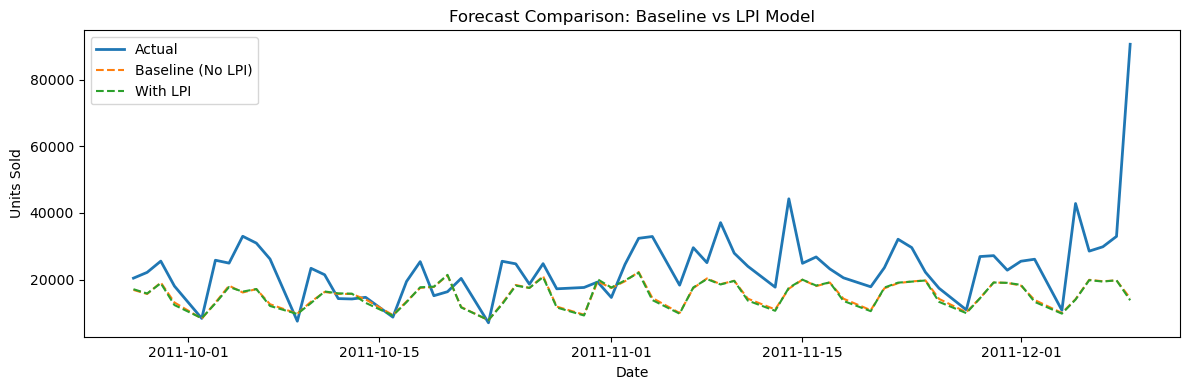

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(
    test_df["Date"],
    test_df[target].values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_df["Date"],
    pred_base,
    linestyle="--",
    label="Baseline (No LPI)"
)

plt.plot(
    test_df["Date"],
    pred_lpi,
    linestyle="--",
    label="With LPI"
)

plt.title("Forecast Comparison: Baseline vs LPI Model")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
full_df = uk_demand.copy()

baseline_features = [
    "lag_1",
    "lag_7",
    "rolling_7_mean",
    "day_of_week",
    "month"
]

lpi_features = baseline_features + ["LPI_VALUE"]
target = "Demand"

train_df = full_df.dropna(
    subset=lpi_features + [target]
).copy()

X_full = train_df[lpi_features]
y_full = train_df[target]

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_forecast = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_forecast.fit(X_full, y_full)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
forecast_horizon = 30

last_date = full_df["Date"].max()
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq="D"
)

future_df = pd.DataFrame({"Date": future_dates})
future_df["day_of_week"] = future_df["Date"].dt.dayofweek
future_df["month"] = future_df["Date"].dt.month

future_df["LPI_VALUE"] = full_df["LPI_VALUE"].iloc[-1]

In [59]:
history = full_df.copy()
future_predictions = []

for i in range(forecast_horizon):
    current_date = future_df.loc[i, "Date"]

    lag_1 = history.iloc[-1]["Demand"]
    lag_7 = history.iloc[-7]["Demand"] if len(history) >= 7 else history["Demand"].mean()

    rolling_7_mean = history["Demand"].tail(7).mean()

    X_future = pd.DataFrame([{
        "lag_1": lag_1,
        "lag_7": lag_7,
        "rolling_7_mean": rolling_7_mean,
        "day_of_week": future_df.loc[i, "day_of_week"],
        "month": future_df.loc[i, "month"],
        "LPI_VALUE": future_df.loc[i, "LPI_VALUE"]
    }])

    y_pred = rf_forecast.predict(X_future)[0]
    future_predictions.append(y_pred)

    history = pd.concat(
        [history, pd.DataFrame({"Date": [current_date], "Demand": [y_pred]})],
        ignore_index=True
    )

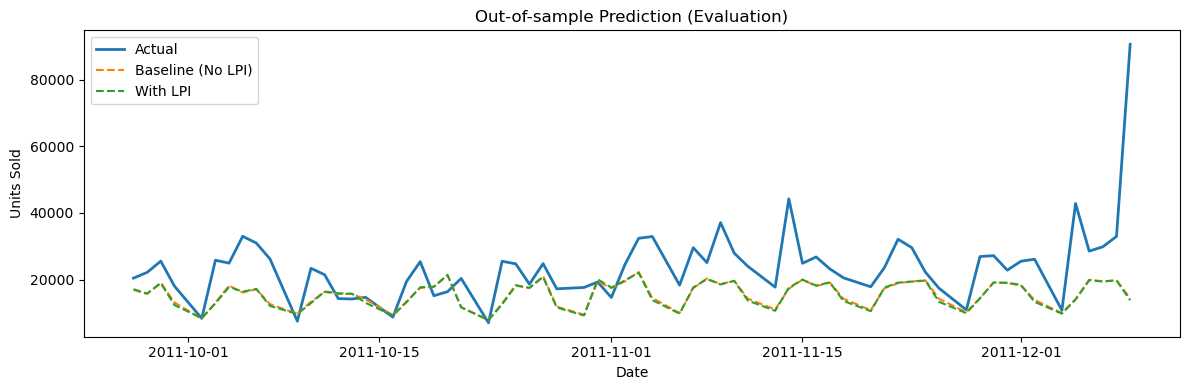

In [62]:
plt.figure(figsize=(12,4))

plt.plot(
    test_df["Date"],
    test_df["Demand"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test_df["Date"],
    pred_base,
    linestyle="--",
    label="Baseline (No LPI)"
)

plt.plot(
    test_df["Date"],
    pred_lpi,
    linestyle="--",
    label="With LPI"
)

plt.title("Out-of-sample Prediction (Evaluation)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
forecast_horizon = 7300

last_date = uk_demand["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq="D"
)

history = uk_demand[["Date", "Demand", "LPI_VALUE"]].copy()
future_predictions = []

for d in future_dates:
    lag_1 = history.iloc[-1]["Demand"]
    lag_7 = history.iloc[-7]["Demand"] if len(history) >= 7 else history["Demand"].mean()
    rolling_7_mean = history["Demand"].tail(7).mean()

    X_future = pd.DataFrame([{
        "lag_1": lag_1,
        "lag_7": lag_7,
        "rolling_7_mean": rolling_7_mean,
        "day_of_week": d.dayofweek,
        "month": d.month,
        "LPI_VALUE": history.iloc[-1]["LPI_VALUE"]
    }])

    y_pred = rf_lpi.predict(X_future)[0]
    future_predictions.append(y_pred)

    history = pd.concat(
        [history, pd.DataFrame({"Date":[d], "Demand":[y_pred], "LPI_VALUE":[history.iloc[-1]["LPI_VALUE"]]})],
        ignore_index=True
    )

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Demand": future_predictions
})

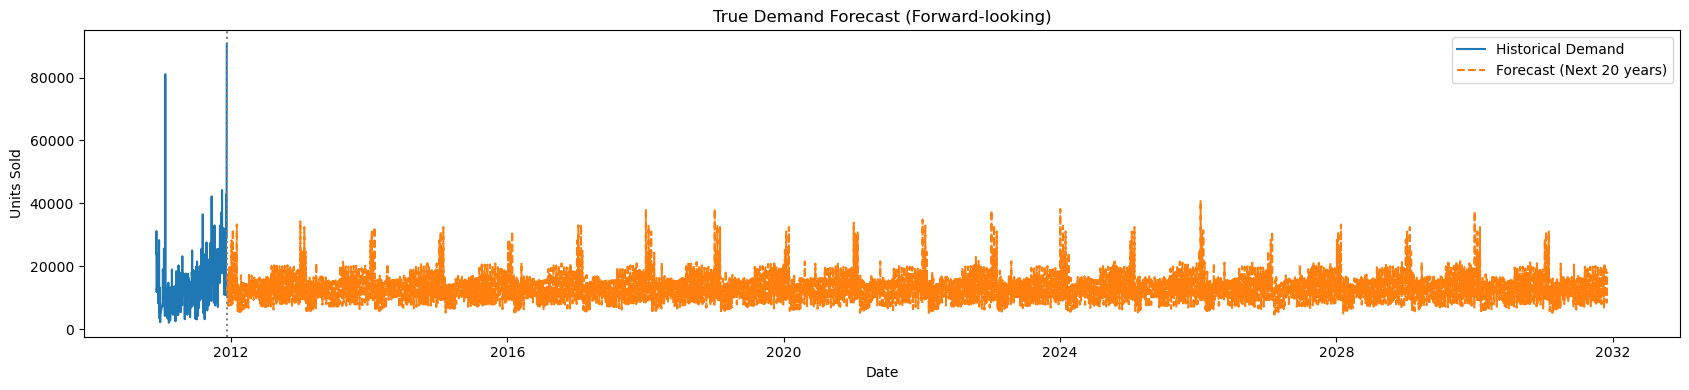

In [71]:
plt.figure(figsize=(17,4))

plt.plot(
    uk_demand["Date"],
    uk_demand["Demand"],
    label="Historical Demand"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast_Demand"],
    linestyle="--",
    label="Forecast (Next 20 years)"
)

plt.axvline(
    uk_demand["Date"].max(),
    color="gray",
    linestyle=":"
)

plt.title("True Demand Forecast (Forward-looking)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()